In [1]:
import h5py
import mrcfile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from torch_em.data.sampler import MinForegroundSampler
from synapse_net.file_utils import read_mrc

### Measure actin occupancy for deepict dataset

In [2]:
LABELS_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/public/deepict/h5")
MASK_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/public/deepict/sample_masks")

label_paths = [p for p in LABELS_DIR.glob("*.h5")] 
mask_paths = [p for p in MASK_DIR.glob("*.mrc")]

In [4]:
def sample_patch_occupancies(labels, mask, patch_shape, n_patches=10, max_tries_per_patch=50):
    rng = np.random.default_rng()
    sampler = MinForegroundSampler(min_fraction=0.95, p_reject=1.0)

    z, y, x = labels.shape
    pz, py, px = patch_shape
    hz, hy, hx = pz//2, py//2, px//2

    # only allow patch centers where the full patch fits inside the volume
    # valid is True at valid centers
    valid = np.zeros_like(mask, dtype=bool)
    valid[hz:z-(pz-hz), hy:y-(py-hy), hx:x-(px-hx)] = True

    # centers must be valid and inside the mask for patch extraction
    candidates = np.argwhere(mask.astype(bool) & valid)
    if len(candidates) == 0:
        raise ValueError("No valid centers inside mask.")
    
    occ = np.empty(n_patches, dtype=np.float32)

    for k in range(n_patches):
        for _ in range(max_tries_per_patch):
            cz, cy, cx = candidates[rng.integers(len(candidates))]
        
            z0, z1 = cz - hz, cz - hz + pz
            y0, y1 = cy - hy, cy - hy + py
            x0, x1 = cx - hx, cx - hx + px

            label_patch = labels[z0:z1, y0:y1, x0:x1]
            mask_patch = mask[z0:z1, y0:y1, x0:x1]
            mask_patch = mask_patch.astype(np.uint8)

            # calculate occupancy (fg voxels / total voxels)
            # only accept patches with 95% masked voxels
            if sampler(label_patch, mask_patch):
                occ[k] = (label_patch == 1).mean()
                break
    
        else:
            raise RuntimeError(
                f"Failed to sample patch with 95% mask coverage after {max_tries_per_patch} tries."
            )
            
    return occ

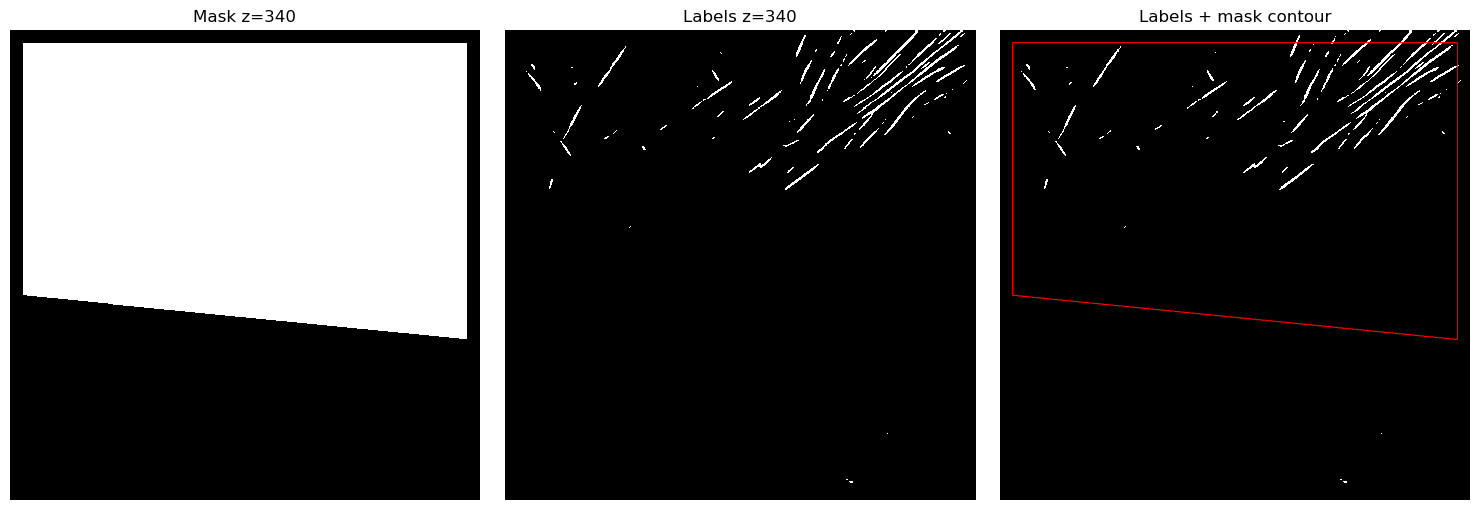

In [ ]:
# check mask alignment
import matplotlib.pyplot as plt

# `read_mrc` applies np.flip() (reflection) to axis 1, need to do the same for h5
with h5py.File(label_paths[0], "r") as f:
    labels = f["labels/actin"][:]
    labels = np.flip(labels, axis = 1)

mask = read_mrc(mask_paths[0])[0]

z = 340

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(mask[z], cmap="gray", interpolation="nearest")
ax[0].set_title(f"Mask z={z}")
ax[0].axis("off")

ax[1].imshow(labels[z], cmap="gray", interpolation="nearest")
ax[1].set_title(f"Labels z={z}")
ax[1].axis("off")

ax[2].imshow(labels[z], cmap="gray", interpolation="nearest")
ax[2].contour(mask[z].astype(bool), levels=[0.5], colors="r", linewidths=0.8)
ax[2].set_title("Labels + mask contour")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
patch_shape = (64, 384, 384)
for label_path, mask_path in zip(label_paths, mask_paths):

    with h5py.File(label_path, "r") as f:
        labels = f["labels/actin"][:]
        labels = np.flip(labels, axis = 1)

    mask = read_mrc(mask_path)[0]

    occ = sample_patch_occupancies(labels, mask, patch_shape)
    
    print(f"occupancies for {mask_path.stem}: {occ}")
    print(f"min: {occ.min()*100:.2f}%, max: {occ.max()*100:.2f}%")
    print(f"average: {occ.mean()*100:.2f}%")

occupancies for 00004: [0.06251749 0.09944132 0.08352152 0.1179001  0.07230049 0.11787754
 0.05160035 0.11697515 0.11910544 0.09989558]
min: 5.16%, max: 11.91%
average: 9.41%
occupancies for 00011: [0.04716449 0.04645453 0.02570068 0.02692604 0.02225102 0.03533628
 0.05310239 0.03754404 0.02688959 0.03595628]
min: 2.23%, max: 5.31%
average: 3.57%


### Visualize deepict simulation results

In [4]:
def visualize_results_5x2(mrc_paths, z=93):

    fig, ax = plt.subplots(2, 5, figsize=(25, 10))

    ax = ax.flatten()

    for i, file in enumerate(mrc_paths): 
        tomo = read_mrc(file)[0][z, :, :]
    
        ax[i].imshow(tomo, cmap="gray")
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()
    
def visualize_results_3x3(mrc_paths, z=93):

    fig, ax = plt.subplots(3, 3, figsize=(15, 15))

    ax = ax.flatten()
    
    for i, file in enumerate(mrc_paths): 
        tomo = read_mrc(file)[0][z, :, :]
    
        ax[i].imshow(tomo, cmap="gray")
        ax[i].axis("off")
        
    plt.tight_layout()
    plt.show()

#### Run 1 - Actin occupancy

Found 10 files.
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task0/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task1/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task2/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task3/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task4/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task5/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task6/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task7/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1/task8/tomos/tomo_den_

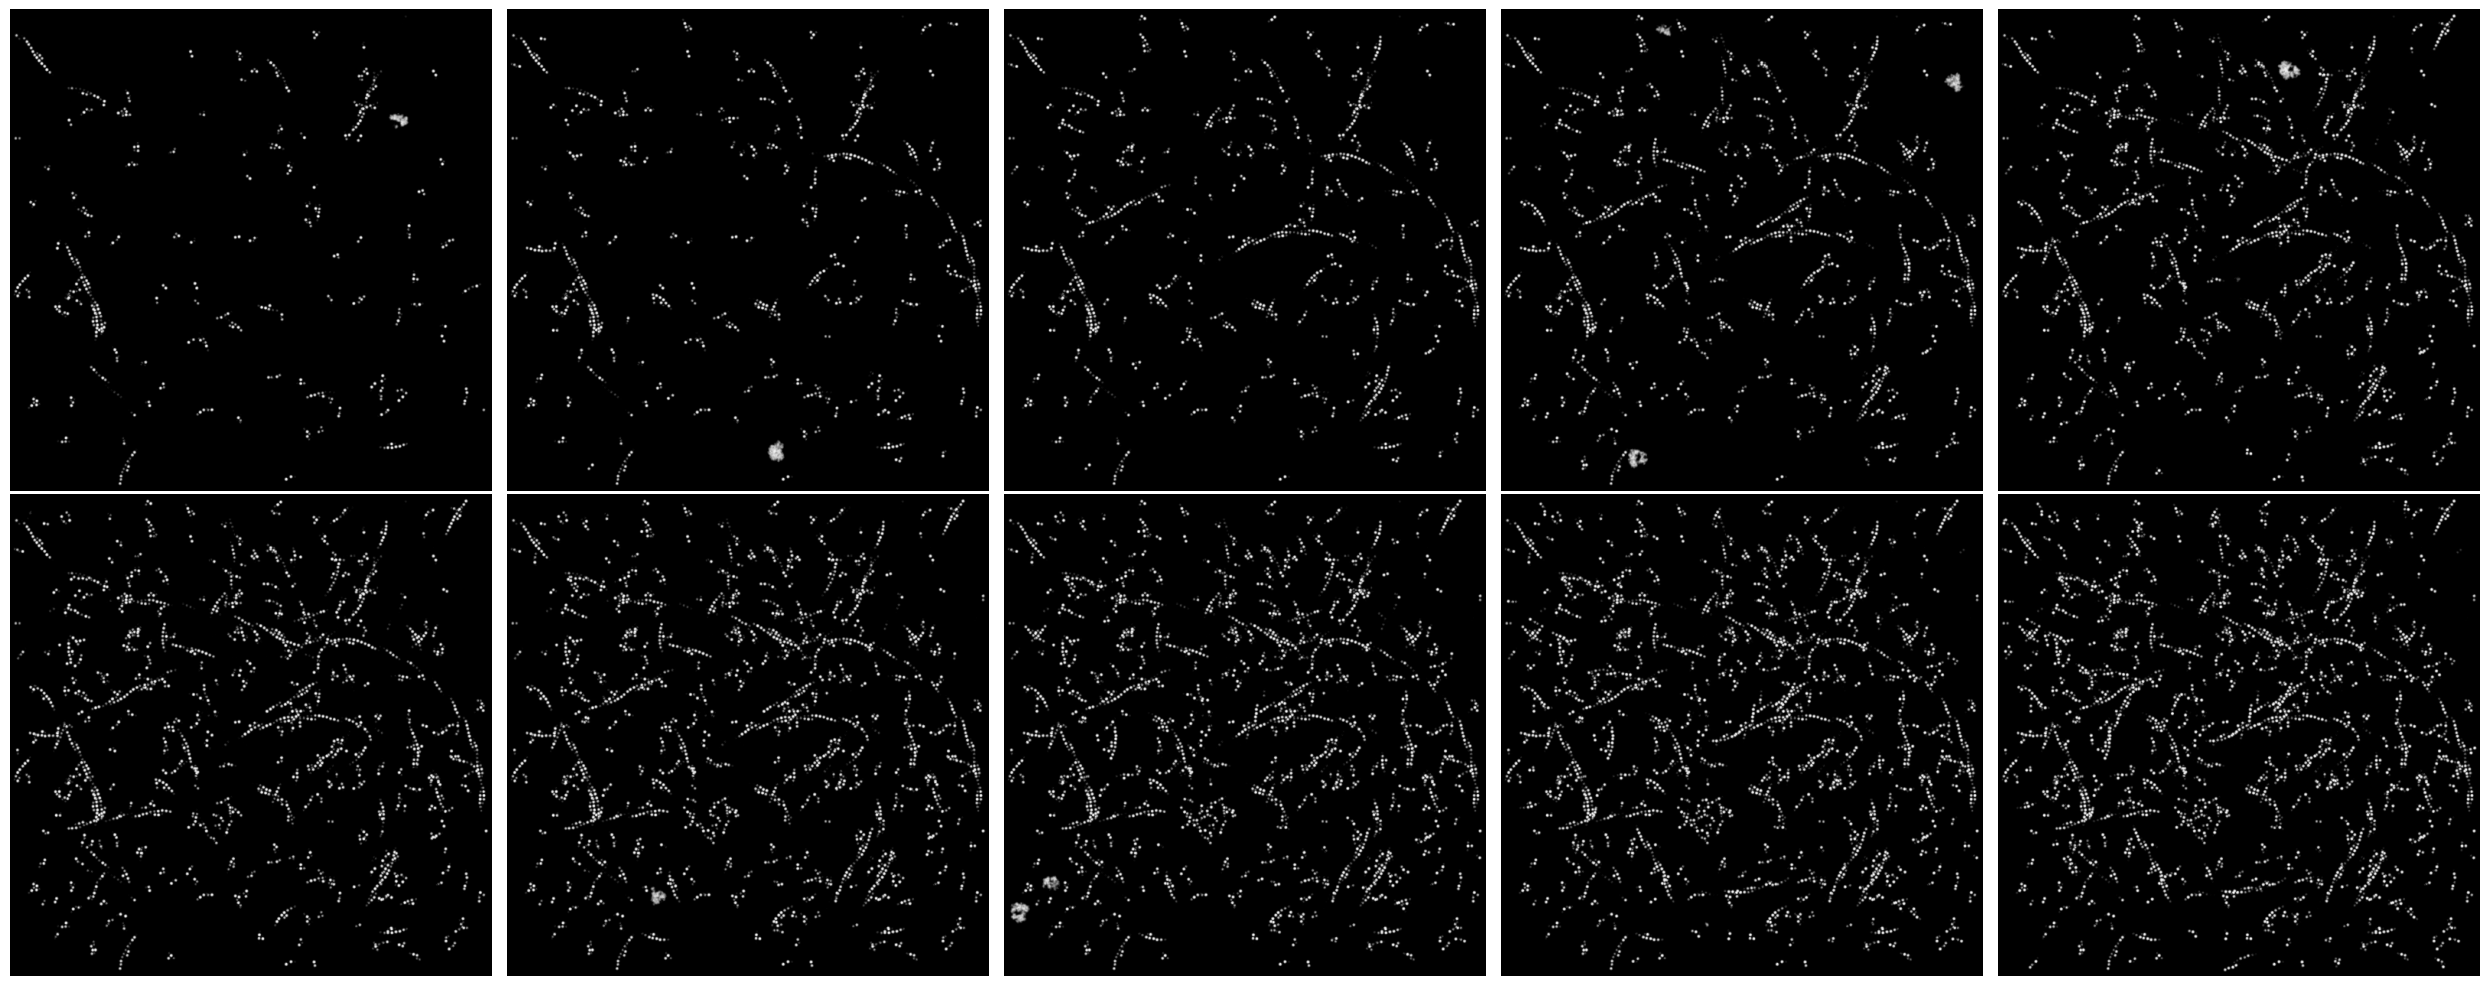

In [22]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run1")

mrc_paths = sorted(PARENT_DIR.glob("task*/tomos/tomo_den_0.mrc"))
print(f"Found {len(mrc_paths)} files.")
for p in mrc_paths:
    print(p)

visualize_results_5x2(mrc_paths)

#### Run 2 - New conditions

Found 9 files.
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_0/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_0/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_0/tomos/tomo_den_2.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_1/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_1/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_1/tomos/tomo_den_2.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_2/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2/simulation_dir_2/tomos/tomo_den_1.mrc
/projects/extern/

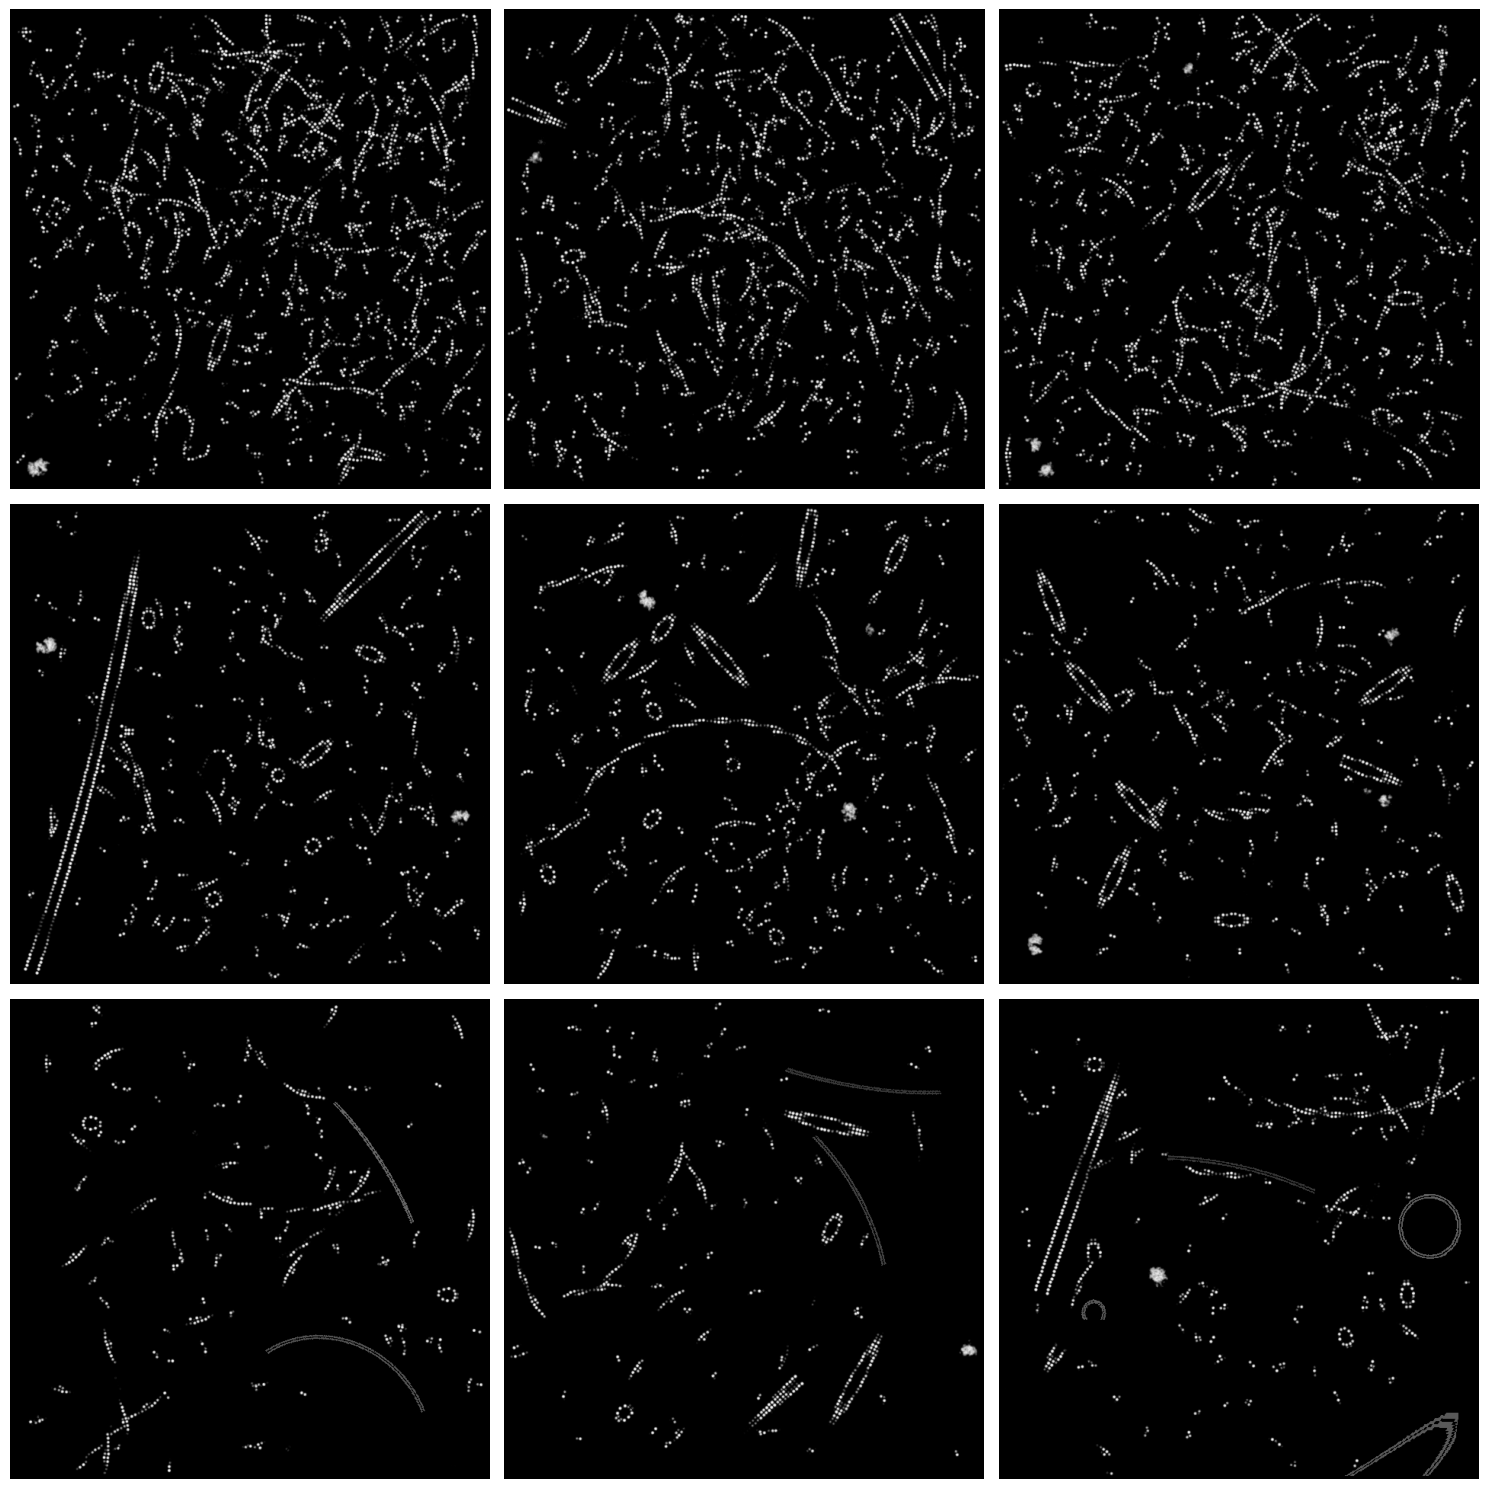

In [ ]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run2")

mrc_paths = sorted(PARENT_DIR.glob("simulation_dir_*/tomos/tomo_den_*.mrc"))

print(f"Found {len(mrc_paths)} files.")
for p in mrc_paths:
    print(p)
    
visualize_results_3x3(mrc_paths, z=40)

#### Run 3 - New conditions

Found 6 files.
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run3/simulation_dir_1/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run3/simulation_dir_1/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run3/simulation_dir_1/tomos/tomo_den_2.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run3/simulation_dir_2/tomos/tomo_den_0.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run3/simulation_dir_2/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run3/simulation_dir_2/tomos/tomo_den_2.mrc


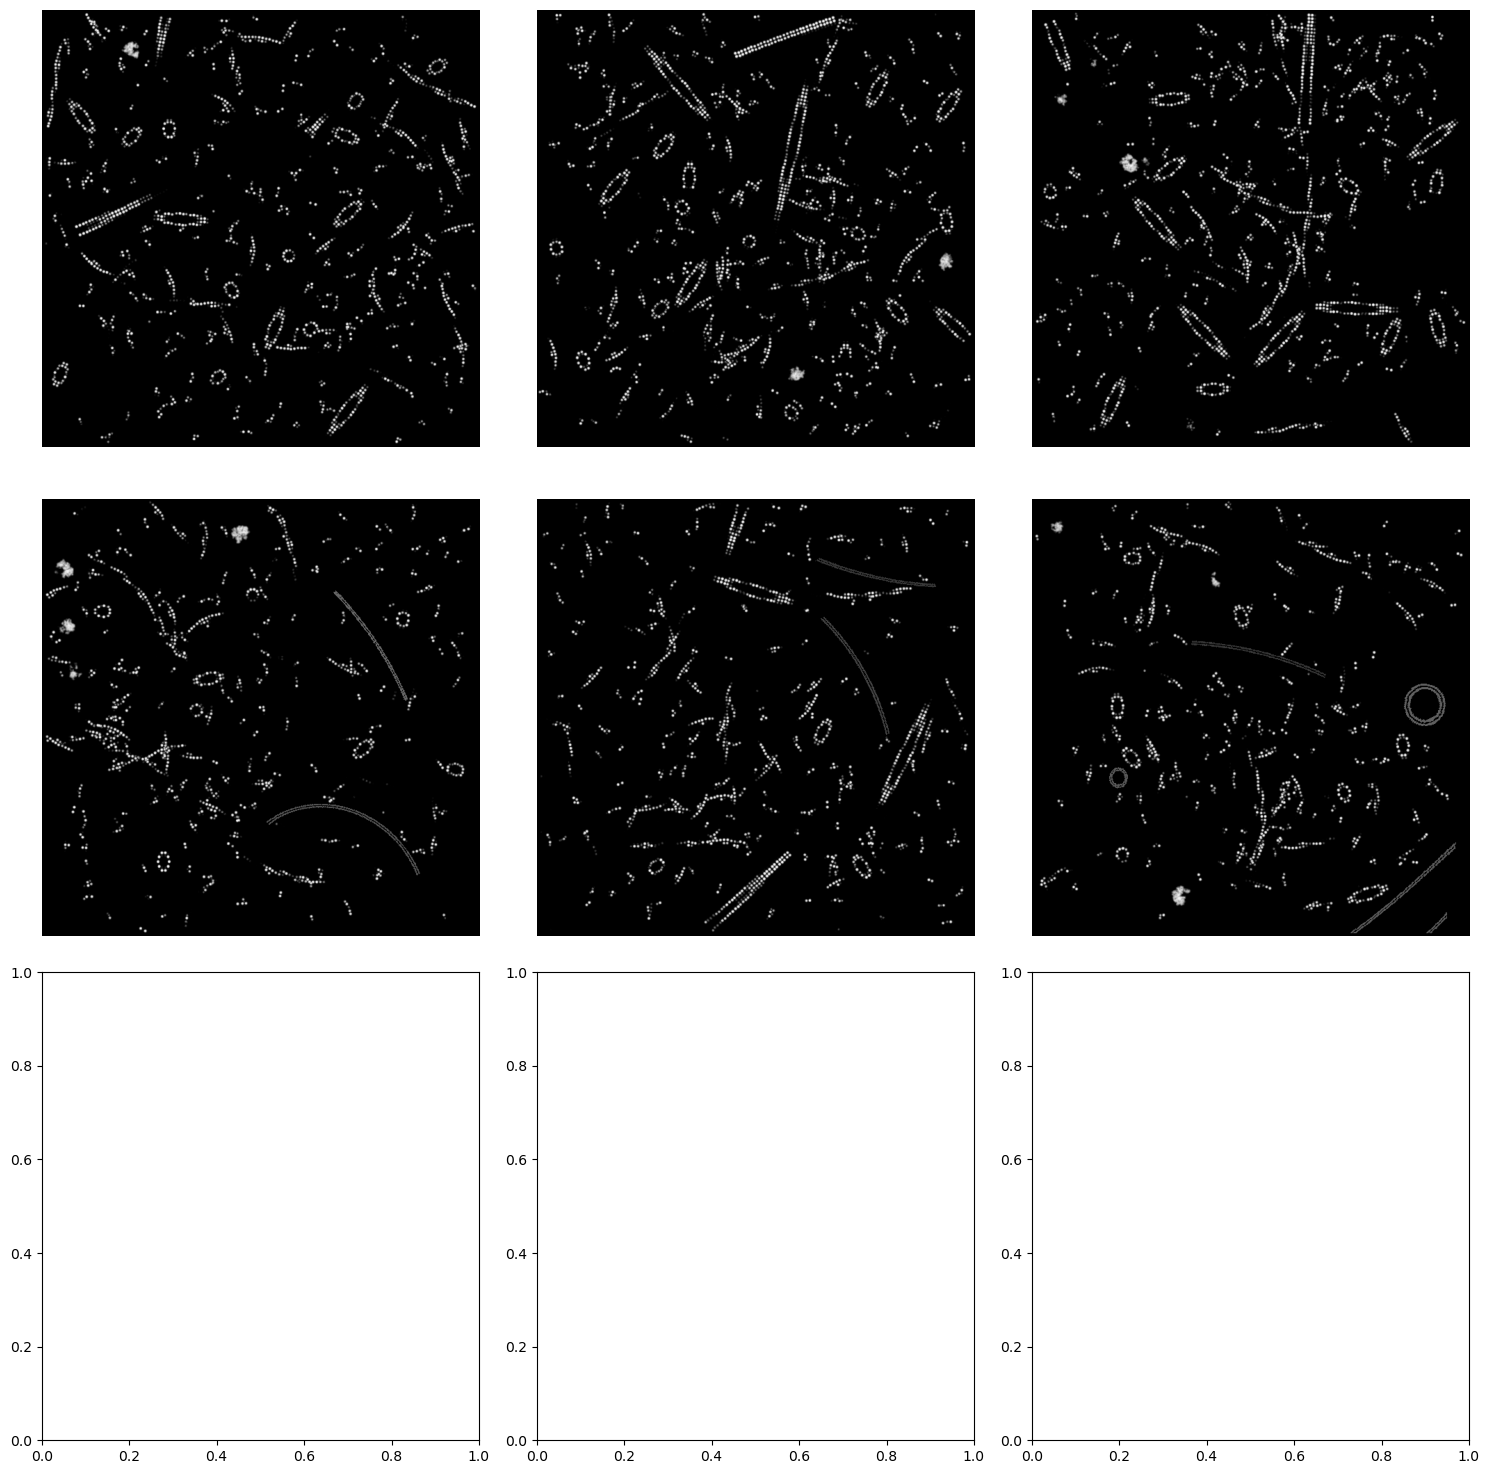

In [5]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run3")

mrc_paths = sorted(PARENT_DIR.glob("simulation_dir_*/tomos/tomo_den_*.mrc"))

print(f"Found {len(mrc_paths)} files.")
for p in mrc_paths:
    print(p)
    
visualize_results_3x3(mrc_paths, z=60)

#### Run 4 - SNR Array

Found 10 files.
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_0/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_1/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_2/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_3/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_4/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_5/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_6/tomos/tomo_den_1.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4/simulation_dir_7/tomos/tomo_den_1.mrc
/projects/extern

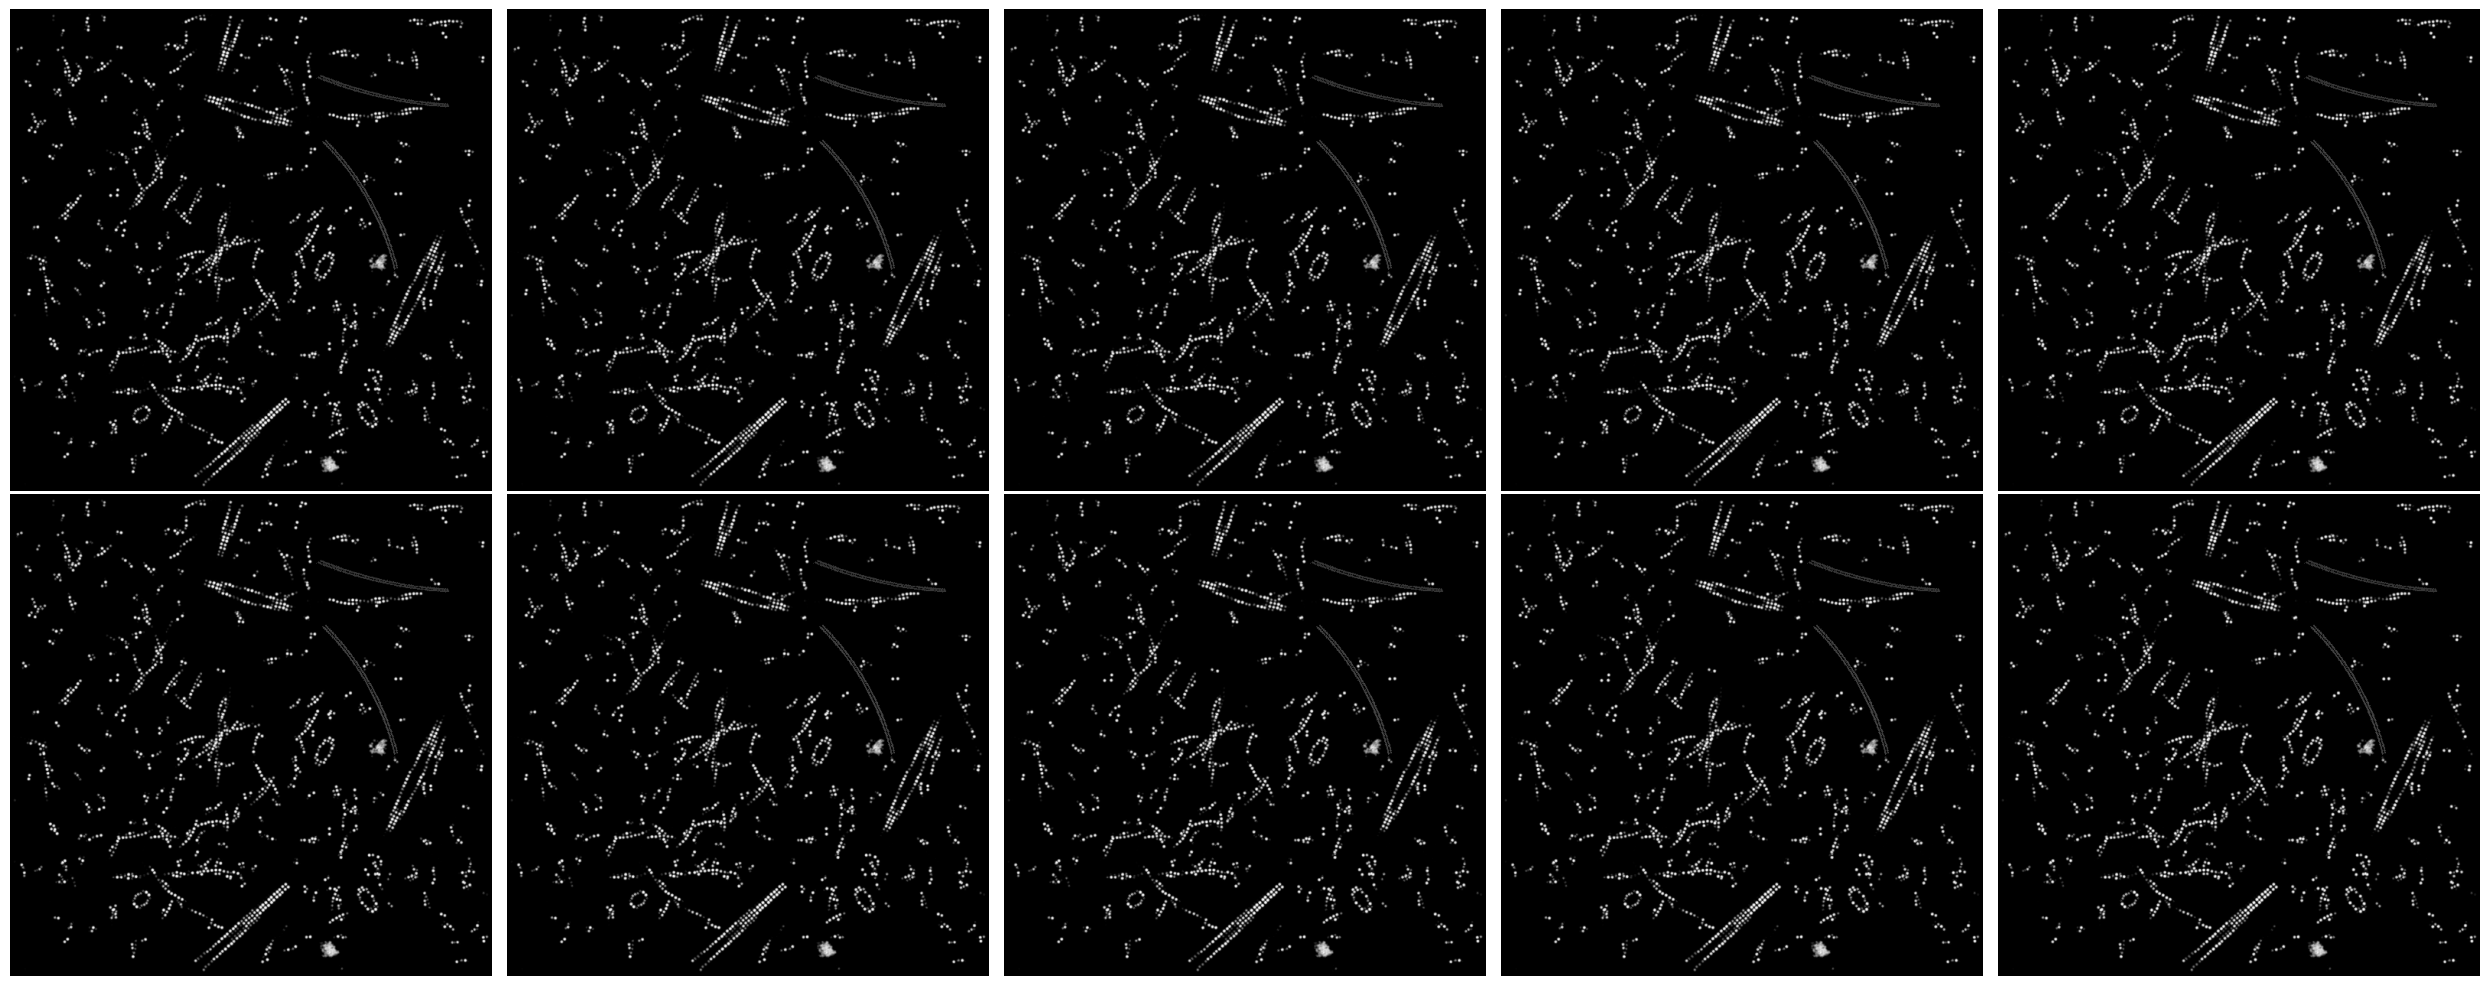

In [6]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run4")

mrc_paths = sorted(PARENT_DIR.glob("simulation_dir_*/tomos/tomo_den_1.mrc"))

print(f"Found {len(mrc_paths)} files.")
for p in mrc_paths:
    print(p)
    
visualize_results_5x2(mrc_paths, z=60)

### Visualize synapse simulation results

#### Run 5 - SNR Array
Range (0.15, 0.20, s)

Found 10 files.
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8/train_dir_0/faket_tomograms/tomogram_1_1_faket.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8/train_dir_1/faket_tomograms/tomogram_1_1_faket.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8/train_dir_2/faket_tomograms/tomogram_1_1_faket.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8/train_dir_3/faket_tomograms/tomogram_1_1_faket.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8/train_dir_4/faket_tomograms/tomogram_1_1_faket.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8/train_dir_5/faket_tomograms/tomogram_1_1_faket.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8/train_dir_6/faket_tomograms/tomogram_1_1_faket.mrc
/projects/extern/nhr/nhr_ni/nim00020/dir.proje

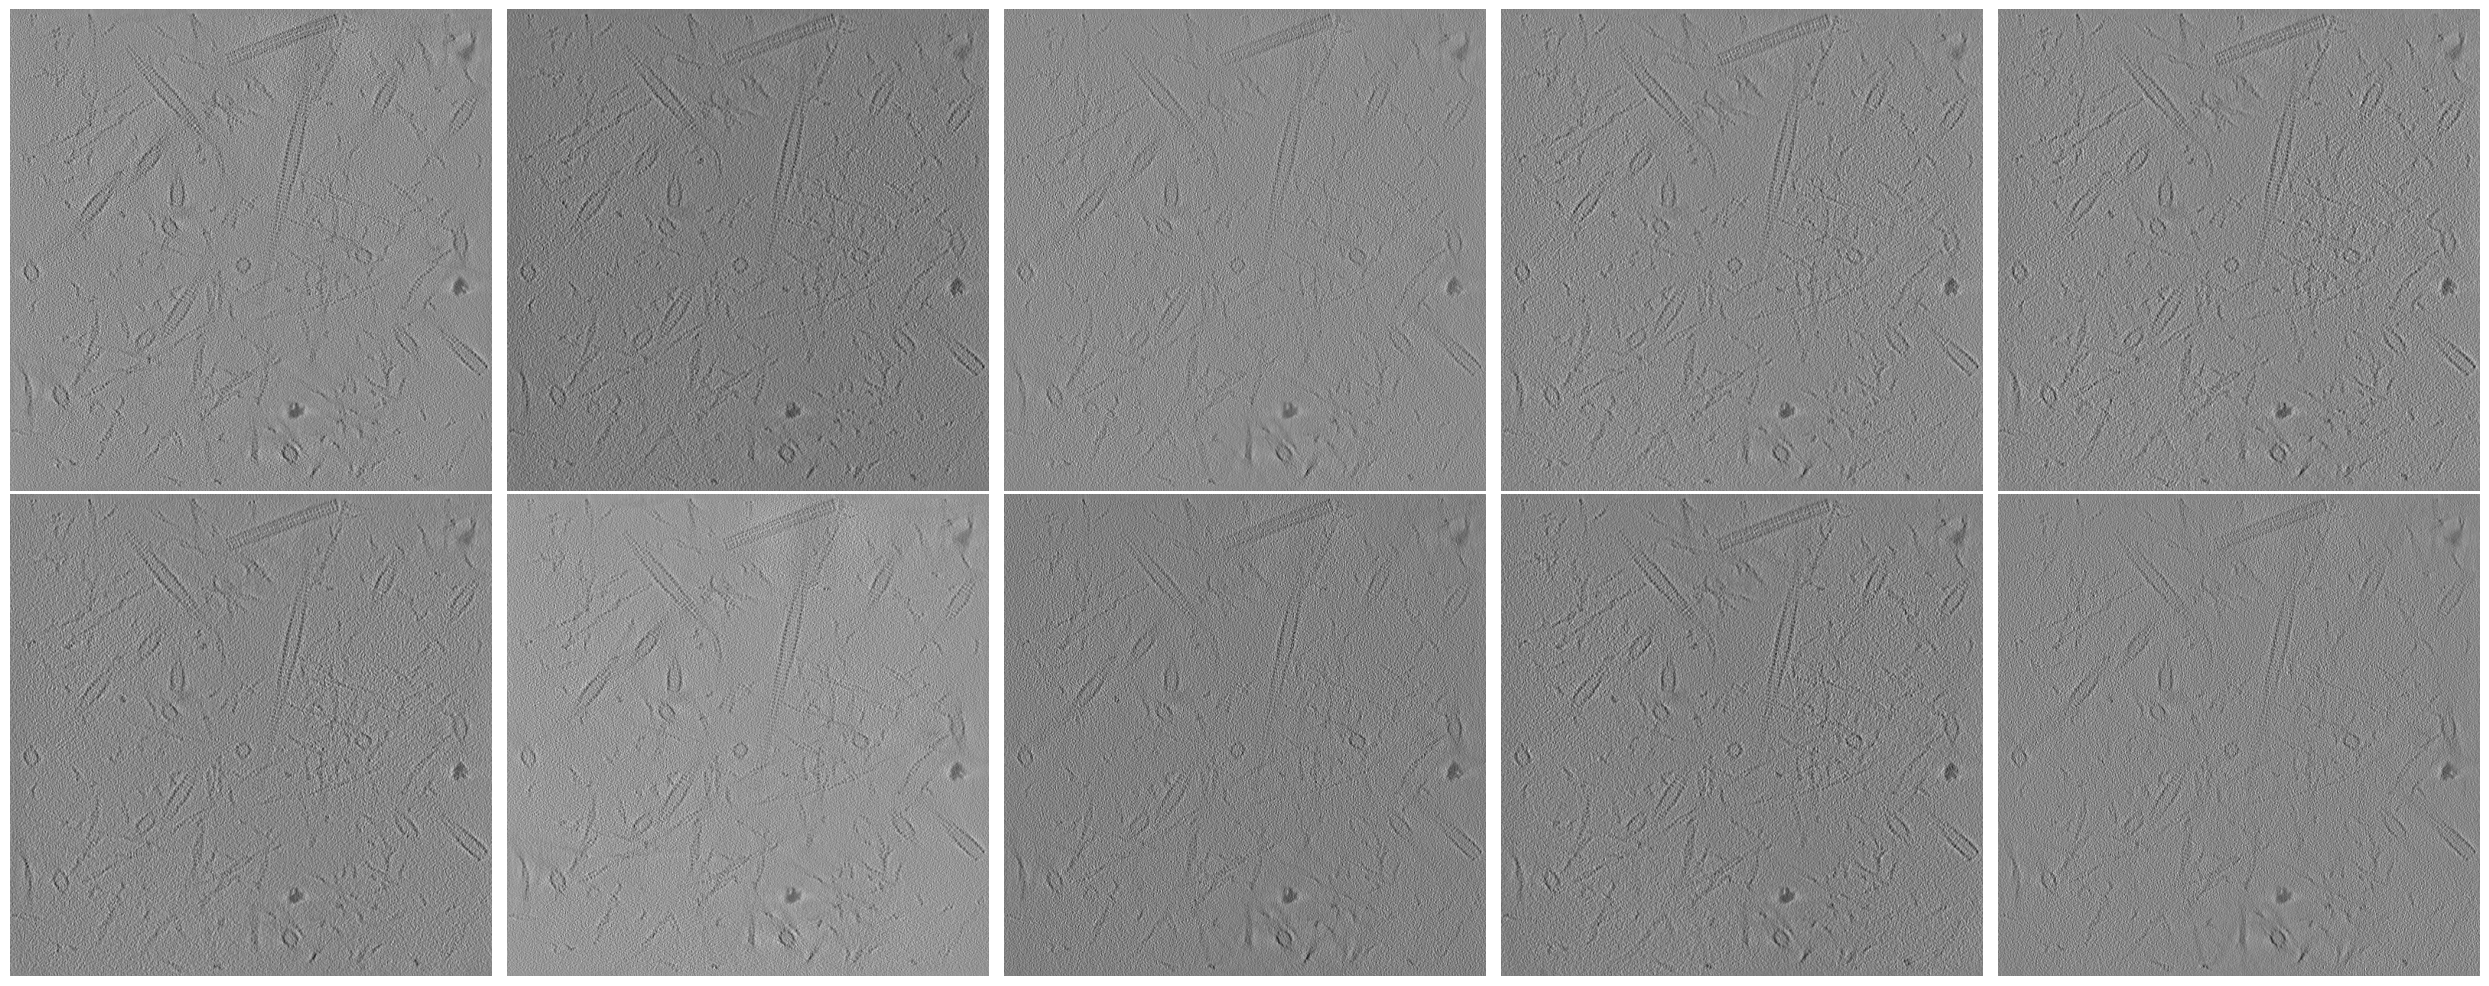

In [9]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/simulation/testing/run8")

mrc_paths = sorted(PARENT_DIR.glob("train_dir_*/faket_tomograms/tomogram_1_1_faket.mrc"))

print(f"Found {len(mrc_paths)} files.")
for p in mrc_paths:
    print(p)
    
visualize_results_5x2(mrc_paths, z=60)

### Resize deepict tomograms

In [2]:
import torch_em

In [14]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/public/deepict/raw")

raw_paths = [str(p) for p in PARENT_DIR.glob("*.mrc")]
        
# read voxel size from mrc to determine the rescale factor
mrc_path = next((p for p in raw_paths if Path(p).suffix == ".mrc"), None)
print(Path(mrc_path).stem)
raw, source_vsize = read_mrc(mrc_path)

target_vsize = 10 
scale = (
        source_vsize["z"] / (target_vsize / 10),
        source_vsize["y"] / (target_vsize / 10),
        source_vsize["x"] / (target_vsize / 10),
        )
print(scale)

rescale_raw = torch_em.transform.generic.Rescale(scale)                

raw = rescale_raw(raw)

out_dir = PARENT_DIR / "rescaled_10A"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "00004.mrc"

with mrcfile.new(out_path, overwrite=True) as mrc:
    mrc.set_data(raw.astype("float32"))
    mrc.voxel_size = (target_vsize, target_vsize, target_vsize)

00004
(np.float32(1.3479999), np.float32(1.3479999), np.float32(1.3479999))


### Testing clDice
Is `SoftSkeletonize` a good approximation for skeletonization? 

I will test this by applying `SoftSkeletonize` on the ground truth labels with different `num_iter`, using `skimage.morphology.skeletonize` as a baseline.

In [2]:
import torch
from torch_em.loss.cldice_loss import SoftSkeletonize
from skimage.morphology import skeletonize
from collections import OrderedDict

ModuleNotFoundError: No module named 'torch_em.loss.cldice_loss'

In [3]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/public/deepict/h5")
data_paths = [p for p in PARENT_DIR.glob("*.h5")]

print(data_paths[0])
with h5py.File(data_paths[0], "r") as f:
    gt_np = f["labels/actin"][:]

/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/public/deepict/h5/00004_cleaned.h5


In [4]:
skimage_skel = skeletonize(gt_np)

gt = torch.from_numpy(gt_np.astype("float32"))
gt = gt.unsqueeze(0)
print(gt.shape)

torch.Size([1, 625, 928, 928])


In [5]:
skels = OrderedDict()

iters = [1, 5, 10, 15]
for it in iters:
    skel_fn = SoftSkeletonize(num_iter=it).cuda()
    with torch.no_grad():
        skel = skel_fn(gt)
    skels[it] = skel.cpu().squeeze(0).numpy()

In [31]:
print(skels[1].shape)

(625, 928, 928)


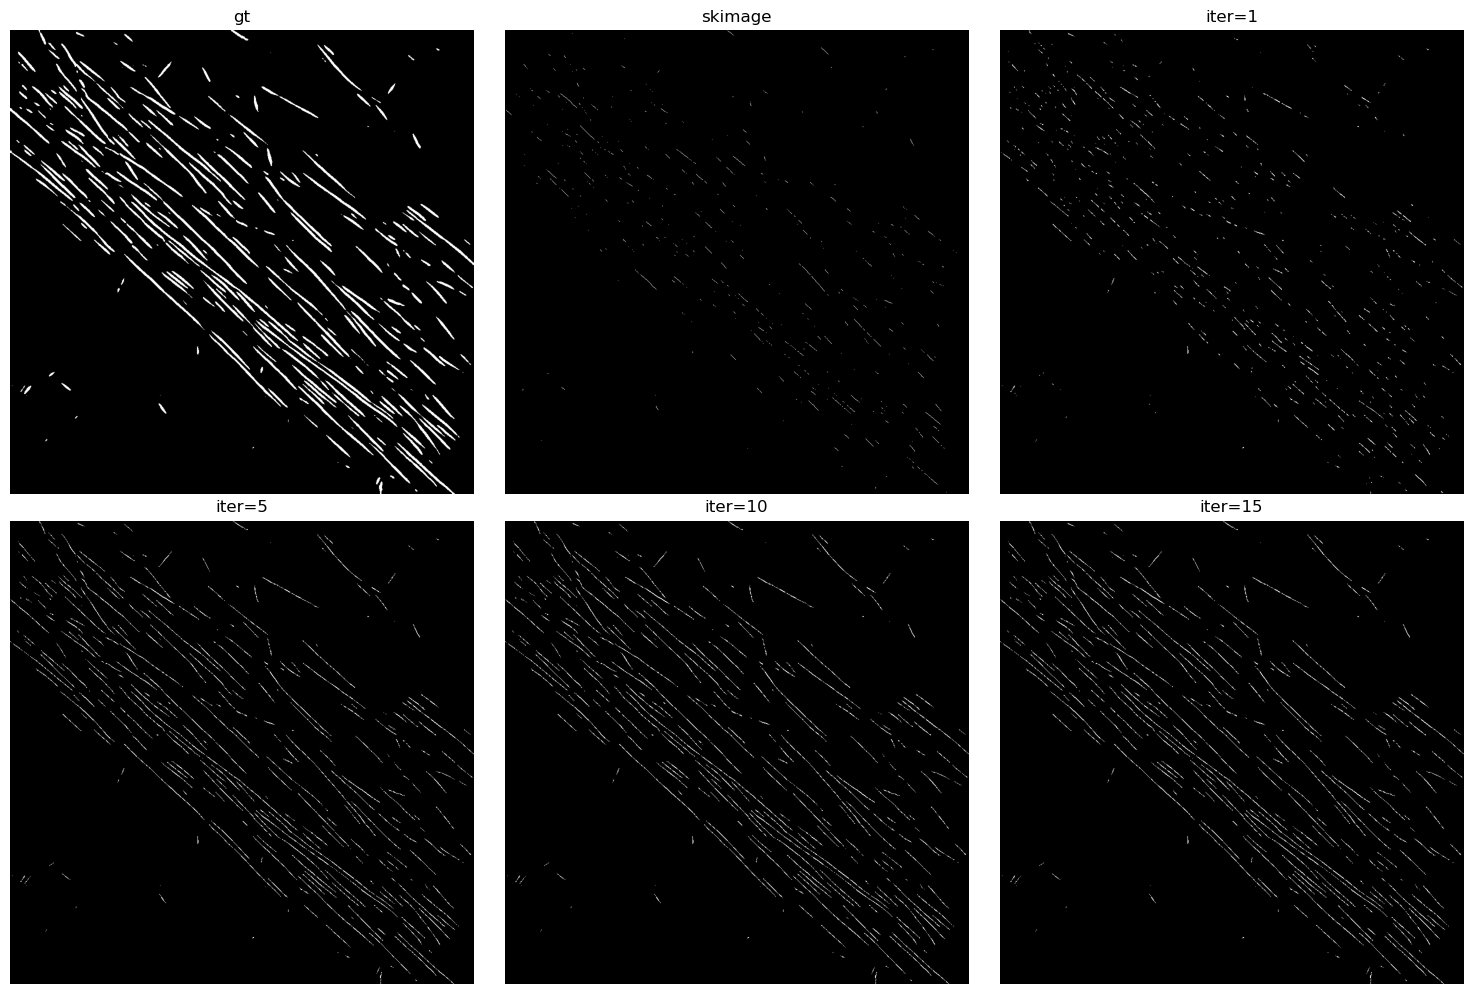

In [6]:
# skeletons are too difficult to visualizate in 2d
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
z = 395
ax = ax.flatten()

ax[0].imshow(gt_np[z, :, :], cmap="gray")
ax[0].set_title("gt")
ax[0].axis("off")
ax[1].imshow(skimage_skel[z, :, :], cmap="gray")
ax[1].set_title("skimage")
ax[1].axis("off")

for i, it in enumerate(iters):
    ax[i+2].imshow(skels[it][z, :, :], cmap="gray")
    ax[i+2].set_title(f"iter={it}")
    ax[i+2].axis("off")
    
plt.tight_layout()
plt.show()

In [10]:
out_path = PARENT_DIR / f"{data_paths[0].stem}_skel.h5"
with h5py.File(out_path, "w") as f:
    f.create_dataset("gt", data=gt, compression="gzip")
    f.create_dataset("skel", data=skimage_skel, compression="gzip")
    f.create_dataset("soft_skel_iter1", data=skels[1], compression="gzip")
    f.create_dataset("soft_skel_iter5", data=skels[5], compression="gzip")

In [9]:
import skimage
# metrics
# clDice - skimage skel (baseline) vs. SoftSkeletonize skels
# Betti error - connected components

# skimage.morphology.skeletonize doesn't seem to work for actin

# instead i will compute the connected components for the soft skeletons and compare with gt
_, num_cc = skimage.measure.label(gt_np, connectivity=2, return_num=True)
print(f"CC for GT: {num_cc}")
for it in iters: 
    _, n_cc = skimage.measure.label(skels[it], connectivity=2, return_num=True)
    print(f"CC for iter={it}: {n_cc}")

CC for GT: 17112
CC for iter=1: 93314
CC for iter=5: 28995
CC for iter=10: 28996
CC for iter=15: 28996


#### Apply `SoftSkeletonize` to simulated data

In [8]:
import torch
from torch_em.loss.cldice import SoftSkeletonize

In [3]:
PARENT_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/training/deepict_dataset_2/test")
data_paths = [p for p in PARENT_DIR.glob("*.h5")]

print(data_paths[0])
with h5py.File(data_paths[0], "r") as f:
    gt_np = f["labels/actin"][:]

gt = torch.from_numpy(gt_np.astype("float32"))
gt = gt.unsqueeze(0)
print(gt.shape)

/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/training/deepict_dataset_2/test/tomogram_0_18.h5
torch.Size([1, 184, 630, 630])


In [10]:
skel_fn = SoftSkeletonize(num_iter=5).cuda()
with torch.no_grad():
    skel = skel_fn(gt)
    skel = skel.cpu().squeeze(0).numpy()

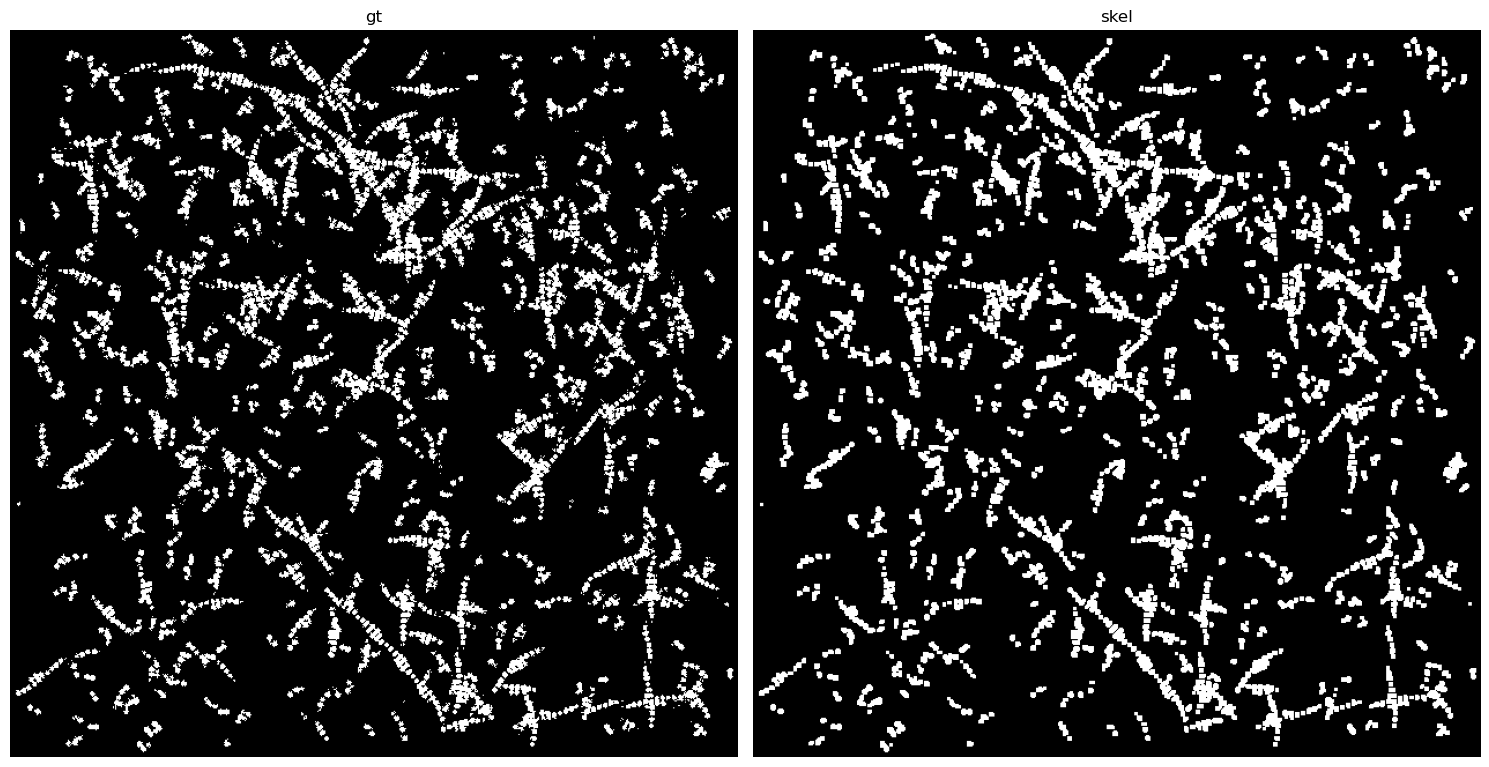

In [11]:
# skeletons are too difficult to visualizate in 2d
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
z = 64
ax[0].imshow(gt_np[z, :, :], cmap="gray")
ax[0].set_title("gt")
ax[0].axis("off")
ax[1].imshow(skel[z, :, :], cmap="gray")
ax[1].set_title("skel")
ax[1].axis("off")
    
plt.tight_layout()
plt.show()